## 1. 环境准备与数据集解压

In [1]:
# 检查 PyTorch 环境
import torch
import torchvision
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 设备: {torch.cuda.get_device_name(0)}")

PyTorch 版本: 2.6.0+cu124
CUDA 是否可用: True
CUDA 版本: 12.4
GPU 设备: NVIDIA GeForce RTX 4090 D


In [2]:
# 解压数据集（如果尚未解压）
import os
import tarfile

data_root = '/home/zhuzhifei/deep Learning'
tar_path = os.path.join(data_root, 'VOCtrainval_11-May-2012.tar')
voc_path = os.path.join(data_root, 'VOCdevkit/VOC2012')

if not os.path.exists(voc_path):
    print('正在解压 VOC2012 数据集...')
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path=data_root)
    print('解压完成！')
else:
    print('数据集已存在，无需解压')

# 检查数据集目录结构
print('\n数据集目录结构:')
for item in os.listdir(voc_path):
    print(f'  - {item}')

正在解压 VOC2012 数据集...
解压完成！

数据集目录结构:
  - Annotations
  - SegmentationObject
  - SegmentationClass
  - ImageSets
  - JPEGImages


## 2. 数据预处理 - 转换灰度标签

In [3]:
import numpy as np
from PIL import Image
import cv2

# VOC2012 颜色标签转换为灰度标签
def convert_color_to_gray(voc_path):
    anno_dir = os.path.join(voc_path, 'SegmentationClass')
    gray_dir = os.path.join(voc_path, 'SegmentationClassGray')
    
    if os.path.exists(gray_dir):
        print('灰度标签已存在！')
        return
    
    os.makedirs(gray_dir)
    print('正在转换彩色标签到灰度标签...')
    
    for ann_file in os.listdir(anno_dir):
        if ann_file.endswith('.png'):  # 只处理 png 标签文件
            ann_path = os.path.join(anno_dir, ann_file)
            ann_im = Image.open(ann_path)
            # VOC 标签是彩色 PNG，转换为灰度（每个颜色对应一个类别）
            ann_array = np.array(ann_im)
            # PIL 的 'P' 模式图像直接保存即为灰度索引
            gray_im = Image.fromarray(ann_array)
            gray_im.save(os.path.join(gray_dir, ann_file))
    
    print(f'转换完成！共 {len(os.listdir(gray_dir))} 个文件')

convert_color_to_gray(voc_path)

正在转换彩色标签到灰度标签...
转换完成！共 2913 个文件


## 3. PyTorch 数据集类定义

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import random

class VOCSegDataset(Dataset):
    """VOC2012 语义分割数据集 (PyTorch 版本)"""
    
    def __init__(self, voc_path, split='train', crop_size=513, 
                 image_mean=[103.53, 116.28, 123.675],
                 image_std=[57.375, 57.120, 58.395],
                 min_scale=0.5, max_scale=2.0,
                 ignore_label=255, is_training=True):
        
        self.voc_path = voc_path
        self.crop_size = crop_size
        self.image_mean = np.array(image_mean, dtype=np.float32)
        self.image_std = np.array(image_std, dtype=np.float32)
        self.min_scale = min_scale
        self.max_scale = max_scale
        self.ignore_label = ignore_label
        self.is_training = is_training
        
        # 目录路径
        self.img_dir = os.path.join(voc_path, 'JPEGImages')
        self.label_dir = os.path.join(voc_path, 'SegmentationClassGray')
        
        # 读取分割列表
        split_file = os.path.join(voc_path, 'ImageSets/Segmentation', f'{split}.txt')
        with open(split_file, 'r') as f:
            self.img_ids = [line.strip() for line in f.readlines()]
        
        print(f'加载 {split} 数据集: {len(self.img_ids)} 张图像')
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        
        # 读取图像 (BGR 格式)
        img_path = os.path.join(self.img_dir, img_id + '.jpg')
        label_path = os.path.join(self.label_dir, img_id + '.png')
        
        image = cv2.imread(img_path)  # BGR
        label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        
        if self.is_training:
            image, label = self._train_transform(image, label)
        else:
            image, label = self._val_transform(image, label)
        
        return image, label
    
    def _train_transform(self, image, label):
        """训练时的数据增强"""
        # 随机缩放
        sc = random.uniform(self.min_scale, self.max_scale)
        new_h, new_w = int(sc * image.shape[0]), int(sc * image.shape[1])
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        label = cv2.resize(label, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
        # 归一化 (BGR 顺序)
        image = (image - self.image_mean) / self.image_std
        
        # Padding 到 crop_size
        h, w = image.shape[:2]
        pad_h = max(self.crop_size - h, 0)
        pad_w = max(self.crop_size - w, 0)
        
        if pad_h > 0 or pad_w > 0:
            image = cv2.copyMakeBorder(image, 0, pad_h, 0, pad_w, 
                                       cv2.BORDER_CONSTANT, value=0)
            label = cv2.copyMakeBorder(label, 0, pad_h, 0, pad_w, 
                                       cv2.BORDER_CONSTANT, value=self.ignore_label)
        
        # 随机裁剪
        h, w = image.shape[:2]
        offset_h = random.randint(0, h - self.crop_size)
        offset_w = random.randint(0, w - self.crop_size)
        
        image = image[offset_h:offset_h+self.crop_size, 
                      offset_w:offset_w+self.crop_size]
        label = label[offset_h:offset_h+self.crop_size, 
                      offset_w:offset_w+self.crop_size]
        
        # 随机水平翻转
        if random.random() > 0.5:
            image = image[:, ::-1, :].copy()
            label = label[:, ::-1].copy()
        
        # HWC -> CHW
        image = image.transpose(2, 0, 1).copy()
        
        return torch.from_numpy(image).float(), torch.from_numpy(label).long()
    
    def _val_transform(self, image, label):
        """验证时的预处理"""
        # 归一化
        image = (image - self.image_mean) / self.image_std
        
        # HWC -> CHW
        image = image.transpose(2, 0, 1).copy()
        
        return torch.from_numpy(image).float(), torch.from_numpy(label).long()

In [5]:
# 创建数据集和数据加载器
def create_dataloaders(voc_path, batch_size=4, crop_size=513, num_workers=4):
    
    train_dataset = VOCSegDataset(
        voc_path, split='train', crop_size=crop_size,
        is_training=True
    )
    
    val_dataset = VOCSegDataset(
        voc_path, split='val', crop_size=crop_size,
        is_training=False
    )
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, 
        shuffle=True, num_workers=num_workers, 
        drop_last=True, pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, batch_size=1, 
        shuffle=False, num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader

# 测试数据加载
train_loader, val_loader = create_dataloaders(voc_path, batch_size=4)
print(f'训练集批次数: {len(train_loader)}')
print(f'验证集批次数: {len(val_loader)}')

# 检查数据形状
images, labels = next(iter(train_loader))
print(f'图像批次形状: {images.shape}')  # [B, 3, H, W]
print(f'标签批次形状: {labels.shape}')  # [B, H, W]

加载 train 数据集: 1464 张图像
加载 val 数据集: 1449 张图像
训练集批次数: 366
验证集批次数: 1449
图像批次形状: torch.Size([4, 3, 513, 513])
标签批次形状: torch.Size([4, 513, 513])


## 4. DeepLabV3 网络结构 (PyTorch 版本)

In [40]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet101

class DeepLabV3(nn.Module):
    """使用 torchvision 预训练 ResNet101 的 DeepLabV3"""
    
    def __init__(self, num_classes=21, freeze_bn=True):
        super(DeepLabV3, self).__init__()
        
        # 加载 torchvision 预训练的 DeepLabV3
        self.model = deeplabv3_resnet101(pretrained=True)
        
        # 修改分类器适应 21 类
        self.model.classifier[-1] = nn.Conv2d(256, num_classes, 1)
        
        # 修改辅助分类器
        if self.model.aux_classifier is not None:
            self.model.aux_classifier[-1] = nn.Conv2d(256, num_classes, 1)
        
        # 冻结 BN 层
        if freeze_bn:
            self._freeze_bn()
    
    def _freeze_bn(self):
        """冻结 BN 层"""
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                for param in m.parameters():
                    param.requires_grad = False
    
    def forward(self, x):
        # torchvision 的 DeepLabV3 返回一个字典
        result = self.model(x)
        # 返回主输出
        return result['out']


In [42]:
# 创建模型
model = DeepLabV3(num_classes=21, freeze_bn=True)
model = model.cuda() if torch.cuda.is_available() else model

# 测试输入
test_input = torch.randn(2, 3, 513, 513)
if torch.cuda.is_available():
    test_input = test_input.cuda()

model.eval()  # 设置为 eval 模式测试
with torch.no_grad():
    test_output = model(test_input)
print(f'输入形状: {test_input.shape}')
print(f'输出形状: {test_output.shape}')  # [2, 21, 513, 513]

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params / 1e6:.2f} M')
print(f'可训练参数量: {trainable_params / 1e6:.2f} M')

model.train()  # 恢复 train 模式


输入形状: torch.Size([2, 3, 513, 513])
输出形状: torch.Size([2, 21, 513, 513])
总参数量: 61.00 M
可训练参数量: 60.89 M


DeepLabV3(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (

## 5. 损失函数与学习率调度

In [43]:
class SegmentationLoss(nn.Module):
    """语义分割损失函数，支持忽略标签"""
    
    def __init__(self, num_classes=21, ignore_label=255):
        super(SegmentationLoss, self).__init__()
        self.num_classes = num_classes
        self.ignore_label = ignore_label
        self.criterion = nn.CrossEntropyLoss(reduction='none', ignore_index=ignore_label)
    
    def forward(self, logits, labels):
        # logits: [B, C, H, W], labels: [B, H, W]
        loss = self.criterion(logits, labels)
        
        # 计算有效像素的平均损失
        valid_mask = (labels != self.ignore_label)
        valid_loss = loss[valid_mask]
        
        if valid_loss.numel() > 0:
            return valid_loss.mean()
        else:
            return loss.mean() * 0  # 返回 0


# 学习率调度器
def get_lr_scheduler(lr_type, base_lr, total_steps, decay_steps=None, 
                      decay_rate=0.1, end_lr=0.0, power=0.9):
    """生成学习率列表"""
    lrs = []
    
    if lr_type == 'cos':
        for i in range(total_steps):
            step = min(i, decay_steps or total_steps)
            lr = base_lr * 0.5 * (1 + np.cos(np.pi * step / (decay_steps or total_steps)))
            lrs.append(lr)
    
    elif lr_type == 'poly':
        for i in range(total_steps):
            step = min(i, decay_steps or total_steps)
            lr = (base_lr - end_lr) * ((1 - step / (decay_steps or total_steps)) ** power) + end_lr
            lrs.append(lr)
    
    elif lr_type == 'exp':
        for i in range(total_steps):
            power_ = i // decay_steps
            lr = base_lr * (decay_rate ** power_)
            lrs.append(lr)
    
    else:
        raise ValueError(f'未知的学习率类型: {lr_type}')
    
    return lrs

## 6. 训练函数

In [44]:
import time
import pickle

from tqdm import tqdm

def train_model(model, train_loader, val_loader, config, save_dir='model'):
    """训练 DeepLabV3 模型"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # 损失函数
    criterion = SegmentationLoss(config['num_classes'], config['ignore_label'])
    
    # 计算训练步数
    iters_per_epoch = len(train_loader)
    total_steps = iters_per_epoch * config['train_epochs']
    
    # 学习率调度
    lrs = get_lr_scheduler(
        config['lr_type'], config['base_lr'], total_steps,
        decay_steps=total_steps
    )
    
    # 优化器
    optimizer = torch.optim.SGD(
        model.parameters(), lr=config['base_lr'], 
        momentum=0.9, weight_decay=0.0001
    )
    
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    # ===== 新增：记录训练数据 =====
    train_losses = []        # 记录每个 step 的 loss
    epoch_losses = []        # 记录每个 epoch 的平均 loss
    epoch_miou = []          # 记录每个 epoch 的 mIoU
    learning_rates = []      # 记录学习率变化
    # ===== 结束新增 =====
    
    best_miou = 0.0
    
    print(f'开始训练: {config["train_epochs"]} epochs, {total_steps} steps')
    print(f'设备: {device}')
    
    global_step = 0
    for epoch in range(config['train_epochs']):
        model.train()
        epoch_loss = 0.0
        epoch_start = time.time()
        
        # 训练一个 epoch
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["train_epochs"]}')
        for batch_idx, (images, labels) in enumerate(pbar):
            # 设置当前学习率
            lr = lrs[global_step]
            optimizer.param_groups[0]['lr'] = lr
            
            # ===== 新增：记录学习率 =====
            learning_rates.append(lr)
            # ===== 结束新增 =====
            
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            global_step += 1
            
            # ===== 新增：记录 loss =====
            train_losses.append(loss.item())
            # ===== 结束新增 =====
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 
                             'lr': f'{lr:.6f}'})
        
        epoch_time = time.time() - epoch_start
        avg_loss = epoch_loss / iters_per_epoch
        
        # ===== 新增：记录 epoch 平均 loss =====
        epoch_losses.append(avg_loss)
        # ===== 结束新增 =====
        
        print(f'Epoch {epoch+1} 完成: 平均损失 {avg_loss:.4f}, 耗时 {epoch_time:.1f}s, 每 step {epoch_time/iters_per_epoch:.2f}s')
        
        # 验证
        if (epoch + 1) % 1 == 0:
            miou = evaluate_model(model, val_loader, config['num_classes'], 
                                  config['ignore_label'], device)
            print(f'验证 mIoU: {miou:.4f}')
            
            # ===== 新增：记录 mIoU =====
            epoch_miou.append(miou)
            # ===== 结束新增 =====
            
            if miou > best_miou:
                best_miou = miou
                save_path = os.path.join(save_dir, 'best_model.pth')
                torch.save(model.state_dict(), save_path)
                print(f'保存最佳模型: {save_path}')
        
        # 保存 epoch 模型
        save_path = os.path.join(save_dir, f'deeplabv3_epoch{epoch+1}.pth')
        torch.save(model.state_dict(), save_path)
        print(f'保存模型: {save_path}')
    
    # ===== 新增：保存训练曲线数据 =====
    training_log = {
        'train_losses': train_losses,
        'epoch_losses': epoch_losses,
        'epoch_miou': epoch_miou,
        'learning_rates': learning_rates
    }
    log_path = os.path.join(save_dir, 'training_log.pkl')
    with open(log_path, 'wb') as f:
        pickle.dump(training_log, f)
    print(f'训练日志已保存: {log_path}')
    # ===== 结束新增 =====
    
    print(f'训练完成！最佳 mIoU: {best_miou:.4f}')
    
    # ===== 新增：返回训练记录 =====
    return model, training_log
    # ===== 结束新增 =====


In [45]:
import matplotlib.pyplot as plt
import pickle

def plot_training_curves(training_log, save_path=None):
    """绘制训练曲线"""
    
    train_losses = training_log['train_losses']
    epoch_losses = training_log['epoch_losses']
    epoch_miou = training_log['epoch_miou']
    learning_rates = training_log['learning_rates']
    
    # 创建 2x2 子图
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 训练 Loss 曲线（每个 step）
    axes[0, 0].plot(train_losses, 'b-', alpha=0.7)
    axes[0, 0].set_title('Training Loss (per step)')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Epoch 平均 Loss 曲线
    epochs = range(1, len(epoch_losses) + 1)
    axes[0, 1].plot(epochs, epoch_losses, 'r-o', linewidth=2, markersize=8)
    axes[0, 1].set_title('Average Loss (per epoch)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. mIoU 曲线
    axes[1, 0].plot(epochs, epoch_miou, 'g-o', linewidth=2, markersize=8)
    axes[1, 0].set_title('Validation mIoU (per epoch)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mIoU')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])  # mIoU 范围 0-1
    
    # 4. 学习率曲线
    axes[1, 1].plot(learning_rates, 'c-', alpha=0.7)
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Step')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'曲线图已保存: {save_path}')
    
    plt.show()

# 加载训练日志并绘制曲线
log_path = os.path.join(data_root, 'model', 'training_log.pkl')
if os.path.exists(log_path):
    with open(log_path, 'rb') as f:
        training_log = pickle.load(f)
    
    # 绘制并保存曲线
    curve_path = os.path.join(data_root, 'model', 'training_curves.png')
    plot_training_curves(training_log, save_path=curve_path)
else:
    print('未找到训练日志文件')


未找到训练日志文件


## 7. 验证函数

In [46]:
def evaluate_model(model, val_loader, num_classes=21, ignore_label=255, device=None):
    """计算 mIoU 指标"""
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    
    # 混淆矩阵
    hist = np.zeros((num_classes, num_classes))
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='验证中'):
            images = images.to(device)
            labels = labels.to(device)
            
            # 前向推理
            outputs = model(images)
            preds = outputs.argmax(dim=1)  # [B, H, W]
            
            # 转为 numpy
            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()
            
            # 更新混淆矩阵
            for pred, label in zip(preds, labels):
                # 忽略边界标签
                mask = (label != ignore_label)
                pred = pred[mask]
                label = label[mask]
                
                # 计算混淆矩阵
                hist += _fast_hist(label.flatten(), pred.flatten(), num_classes)
    
    # 计算 IoU
    iu = np.diag(hist) / (hist.sum(1) + hist.sum(0) - np.diag(hist) + 1e-10)
    miou = np.nanmean(iu)
    
    model.train()
    return miou


def _fast_hist(label, pred, n_class):
    """快速计算混淆矩阵"""
    k = (label >= 0) & (label < n_class)
    return np.bincount(n_class * label[k].astype(int) + pred[k], 
                       minlength=n_class ** 2).reshape(n_class, n_class)

In [47]:
# 可视化分割结果
import matplotlib.pyplot as plt
import matplotlib as mpl

# VOC 21 类别的颜色映射
VOC_COLORS = [
    [0, 0, 0],        # 0: background (black)
    [128, 0, 0],      # 1: aeroplane
    [0, 128, 0],      # 2: bicycle
    [128, 128, 0],    # 3: bird
    [0, 0, 128],      # 4: boat
    [128, 0, 128],    # 5: bottle
    [0, 128, 128],    # 6: bus
    [128, 128, 128],  # 7: car
    [64, 0, 0],       # 8: cat
    [192, 0, 0],      # 9: chair
    [64, 128, 0],     # 10: cow
    [192, 128, 0],    # 11: dining table
    [64, 0, 128],     # 12: dog
    [192, 0, 128],    # 13: horse
    [64, 128, 128],   # 14: motorbike
    [192, 128, 128],  # 15: person
    [0, 64, 0],       # 16: potted plant
    [128, 64, 0],     # 17: sheep
    [0, 192, 0],      # 18: sofa
    [128, 192, 0],    # 19: train
    [0, 64, 128],     # 20: tv/monitor
]

VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'dining table', 'dog', 'horse', 'motorbike',
    'person', 'potted plant', 'sheep', 'sofa', 'train',
    'tv/monitor'
]


def decode_segmap(segmap, colors=VOC_COLORS):
    """将分割图转换为彩色图像"""
    h, w = segmap.shape
    color_map = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i, color in enumerate(colors):
        color_map[segmap == i] = color
    
    return color_map


def visualize_prediction(model, dataset, idx=0, device=None):
    """可视化单张图像的分割结果"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    
    # 获取图像和标签
    image, label = dataset[idx]
    image_batch = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_batch)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    # 反归一化图像用于显示
    image_show = image.cpu().numpy().transpose(1, 2, 0)
    image_mean = np.array([103.53, 116.28, 123.675])
    image_std = np.array([57.375, 57.120, 58.395])
    image_show = (image_show * image_std + image_mean).astype(np.uint8)
    image_show = image_show[:, :, ::-1]  # BGR -> RGB
    
    # 解码分割图
    pred_color = decode_segmap(pred)
    label_color = decode_segmap(label.numpy())
    
    # 显示
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_show)
    axes[0].set_title('原始图像')
    axes[0].axis('off')
    
    axes[1].imshow(pred_color)
    axes[1].set_title('预测分割')
    axes[1].axis('off')
    
    axes[2].imshow(label_color)
    axes[2].set_title('真实标签')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 打印类别统计
    pred_classes = np.unique(pred)
    label_classes = np.unique(label.numpy())
    
    print('预测类别:', [VOC_CLASSES[i] for i in pred_classes if i < 21])
    print('真实类别:', [VOC_CLASSES[i] for i in label_classes if i < 21])
    
    model.train()

## 8. 开始训练

In [48]:
# 训练配置
config = {
    'batch_size': 4,          # 批次大小 (根据 GPU 内存调整)
    'crop_size': 513,         # 裁剪尺寸
    'image_mean': [103.53, 116.28, 123.675],
    'image_std': [57.375, 57.120, 58.395],
    'min_scale': 0.5,
    'max_scale': 2.0,
    'ignore_label': 255,
    'num_classes': 21,
    'train_epochs': 10,       # 训练轮数
    'lr_type': 'poly',        # 学习率策略: 'cos', 'poly', 'exp'
    'base_lr': 0.001,         # 基础学习率（微调用小一点）
    'freeze_bn': True,        # 是否冻结 BN
}

print('训练配置:')
for k, v in config.items():
    print(f'  {k}: {v}')


训练配置:
  batch_size: 4
  crop_size: 513
  image_mean: [103.53, 116.28, 123.675]
  image_std: [57.375, 57.12, 58.395]
  min_scale: 0.5
  max_scale: 2.0
  ignore_label: 255
  num_classes: 21
  train_epochs: 10
  lr_type: poly
  base_lr: 0.001
  freeze_bn: True


In [49]:
# 创建数据加载器
train_loader, val_loader = create_dataloaders(
    voc_path, 
    batch_size=config['batch_size'],
    crop_size=config['crop_size'],
    num_workers=4
)

加载 train 数据集: 1464 张图像
加载 val 数据集: 1449 张图像


In [50]:
# 创建模型（使用预训练 ResNet101）
model = DeepLabV3(num_classes=config['num_classes'], freeze_bn=config['freeze_bn'])

print(f'模型创建完成: DeepLabV3 (预训练 ResNet101)')

# 显示参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params / 1e6:.2f} M')
print(f'可训练参数量: {trainable_params / 1e6:.2f} M')


模型创建完成: DeepLabV3 (预训练 ResNet101)
总参数量: 61.00 M
可训练参数量: 60.89 M


开始训练: 10 epochs, 3660 steps
设备: cuda


Epoch 1/10: 100%|██████████| 366/366 [01:12<00:00,  5.04it/s, loss=1.0627, lr=0.000910]


Epoch 1 完成: 平均损失 1.0631, 耗时 72.6s, 每 step 0.20s


验证中: 100%|██████████| 1449/1449 [00:27<00:00, 52.75it/s]


验证 mIoU: 0.2994
保存最佳模型: /home/zhuzhifei/deep Learning/model/best_model.pth
保存模型: /home/zhuzhifei/deep Learning/model/deeplabv3_epoch1.pth


...

验证 mIoU: 0.7458
保存最佳模型: /home/zhuzhifei/deep Learning/model/best_model.pth
保存模型: /home/zhuzhifei/deep Learning/model/deeplabv3_epoch9.pth


Epoch 10/10: 100%|██████████| 366/366 [01:12<00:00,  5.03it/s, loss=0.3508, lr=0.000001]


Epoch 10 完成: 平均损失 0.2475, 耗时 72.8s, 每 step 0.20s


验证中: 100%|██████████| 1449/1449 [00:27<00:00, 53.52it/s]


验证 mIoU: 0.7483
保存最佳模型: /home/zhuzhifei/deep Learning/model/best_model.pth
保存模型: /home/zhuzhifei/deep Learning/model/deeplabv3_epoch10.pth
训练日志已保存: /home/zhuzhifei/deep Learning/model/training_log.pkl
训练完成！最佳 mIoU: 0.7483
曲线图已保存: /home/zhuzhifei/deep Learning/model/training_curves.png


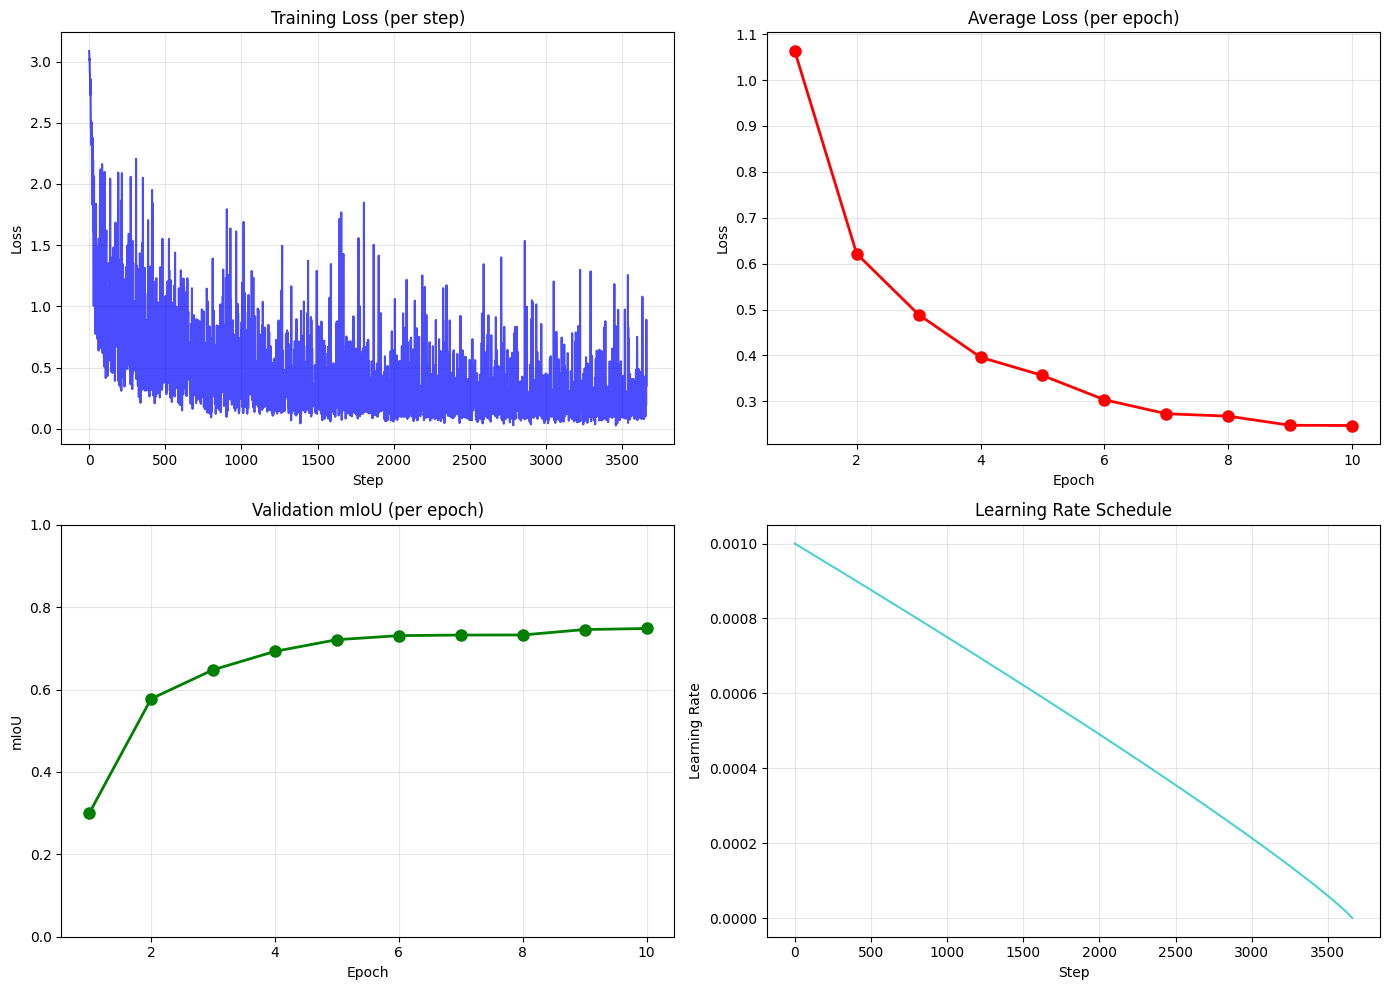

In [51]:
# 开始训练
save_dir = os.path.join(data_root, 'model')
trained_model, training_log = train_model(model, train_loader, val_loader, config, save_dir)

# 直接绘制曲线（不需要重新加载文件）
plot_training_curves(training_log, save_path=os.path.join(save_dir, 'training_curves.png'))


## 9. 加载模型并可视化结果

In [52]:
# 加载训练好的模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载最佳模型
best_model_path = os.path.join(data_root, 'model', 'best_model.pth')
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f'加载模型: {best_model_path}')
else:
    # 尝试加载最后的 epoch 模型
    last_model_path = os.path.join(data_root, 'model', f'deeplabv3_epoch{config["train_epochs"]}.pth')
    if os.path.exists(last_model_path):
        model.load_state_dict(torch.load(last_model_path, map_location=device))
        print(f'加载模型: {last_model_path}')
    else:
        print('未找到保存的模型，使用当前模型状态')

model = model.to(device)


加载模型: /home/zhuzhifei/deep Learning/model/best_model.pth


加载 val 数据集: 1449 张图像

Finding BEST segmentations (lowest error rate)...
Evaluating 1449 samples...

Top 5 Best Segmentations (Lowest Error Rate):

[Rank 1] Error Rate: 0.00%, FP: 0, FN: 0, FG: 15734


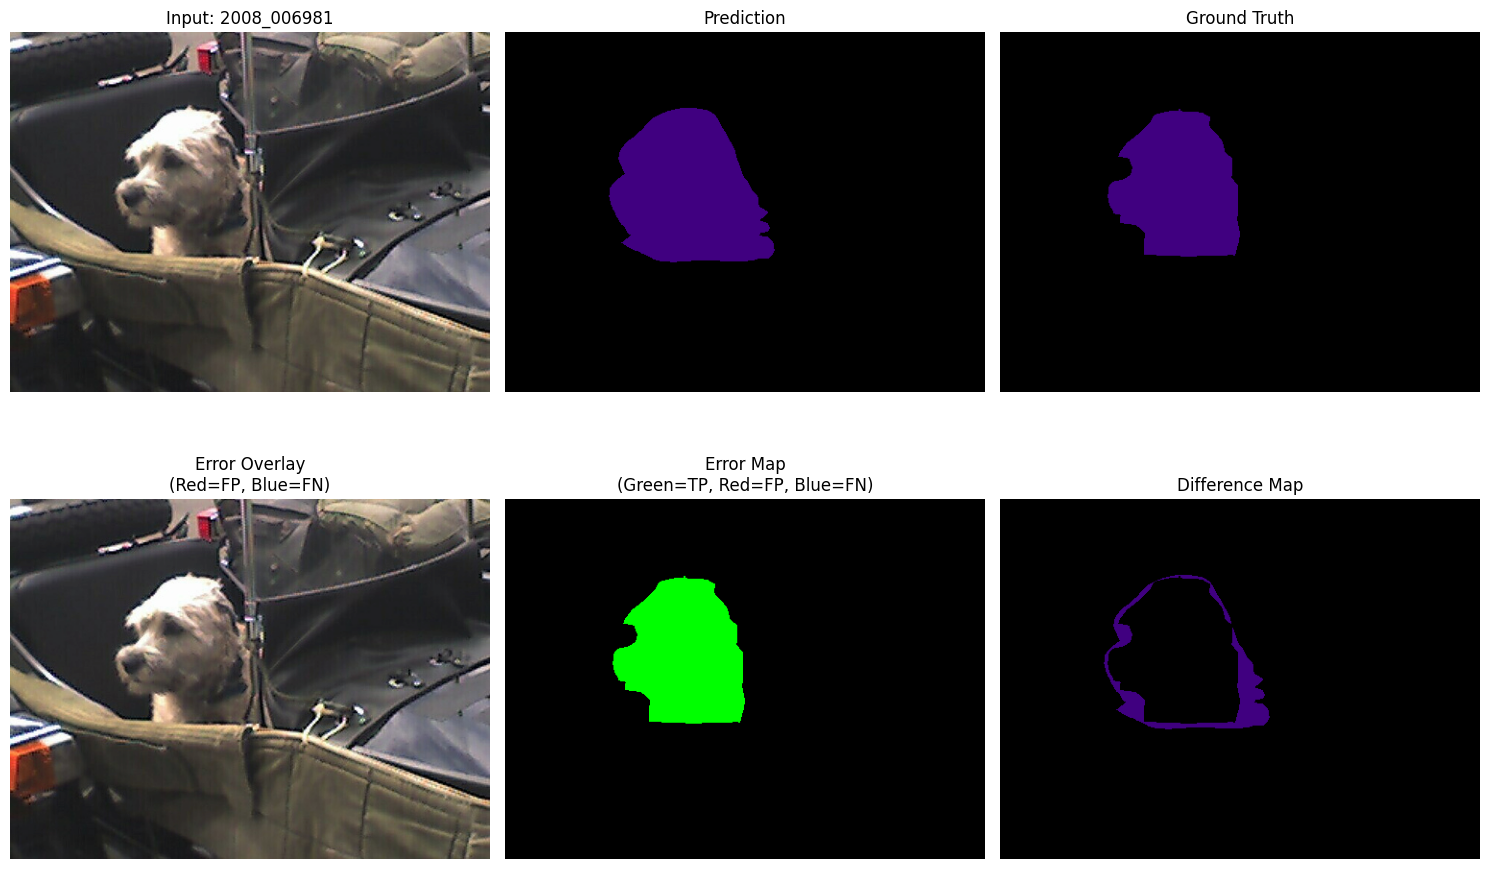

Image: 2008_006981
Foreground pixels: 15734
True Positive (TP): 15734 (100.0%)
False Positive (FP): 0 (extra predictions)
False Negative (FN): 0 (missed regions)
FP + FN total errors: 0
--------------------------------------------------
[Rank 2] Error Rate: 0.03%, FP: 14, FN: 15, FG: 93217


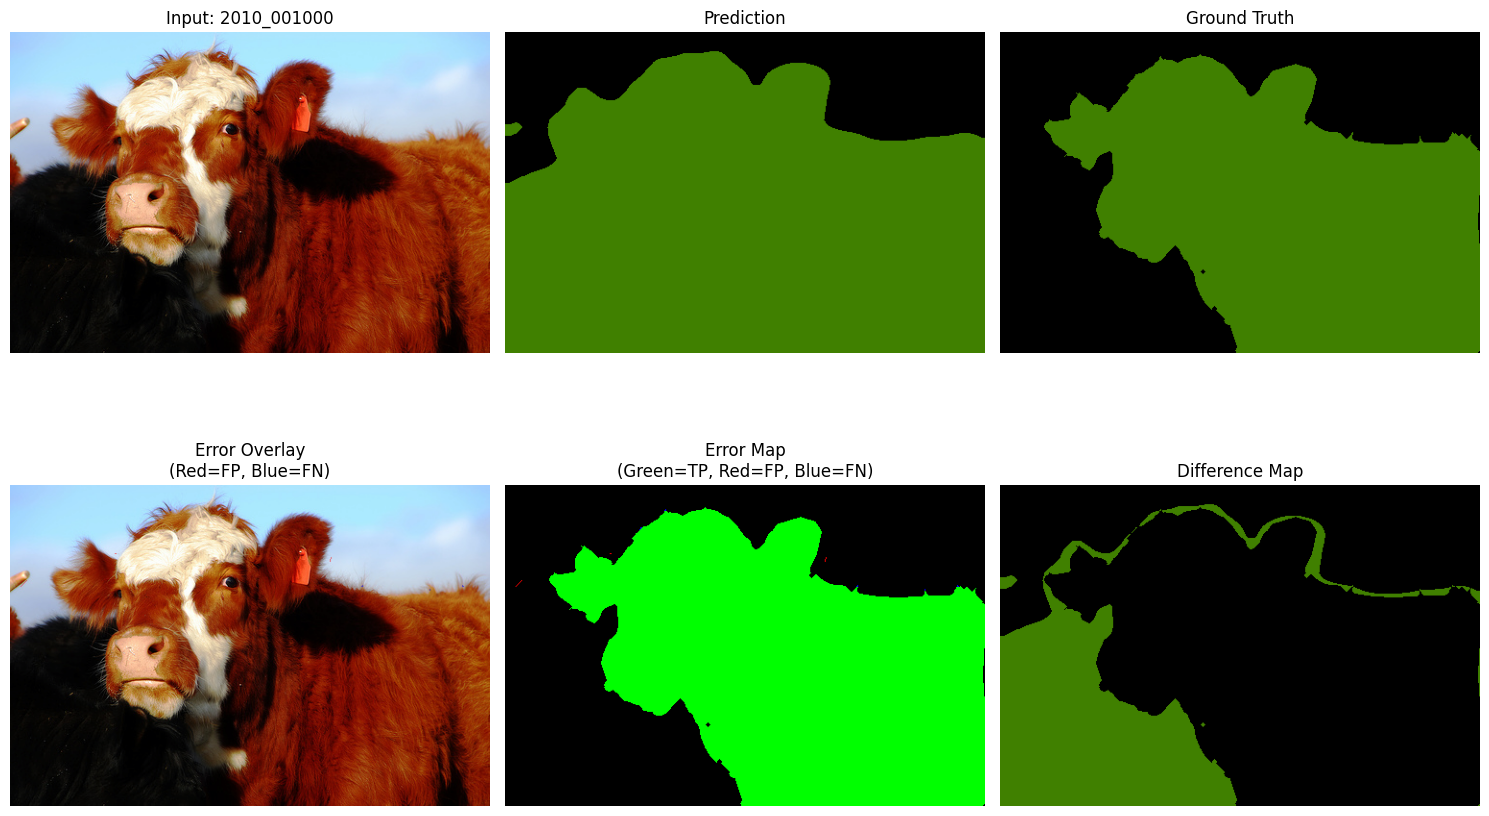

Image: 2010_001000
Foreground pixels: 93217
True Positive (TP): 93202 (100.0%)
False Positive (FP): 14 (extra predictions)
False Negative (FN): 15 (missed regions)
FP + FN total errors: 29
--------------------------------------------------
[Rank 3] Error Rate: 0.05%, FP: 36, FN: 0, FG: 75611


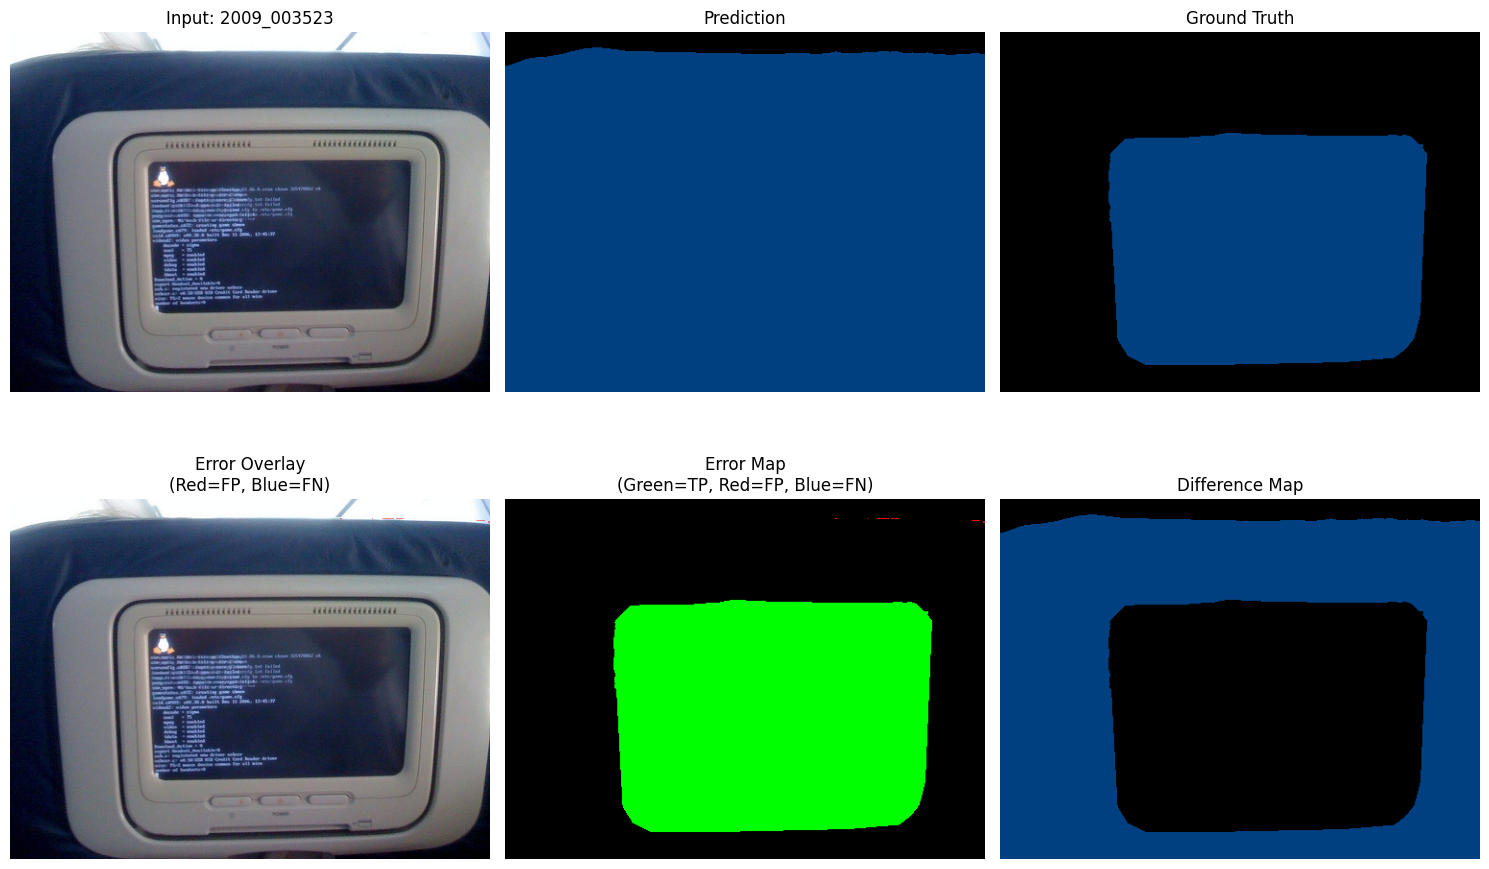

Image: 2009_003523
Foreground pixels: 75611
True Positive (TP): 75611 (100.0%)
False Positive (FP): 36 (extra predictions)
False Negative (FN): 0 (missed regions)
FP + FN total errors: 36
--------------------------------------------------
[Rank 4] Error Rate: 0.21%, FP: 42, FN: 207, FG: 118466


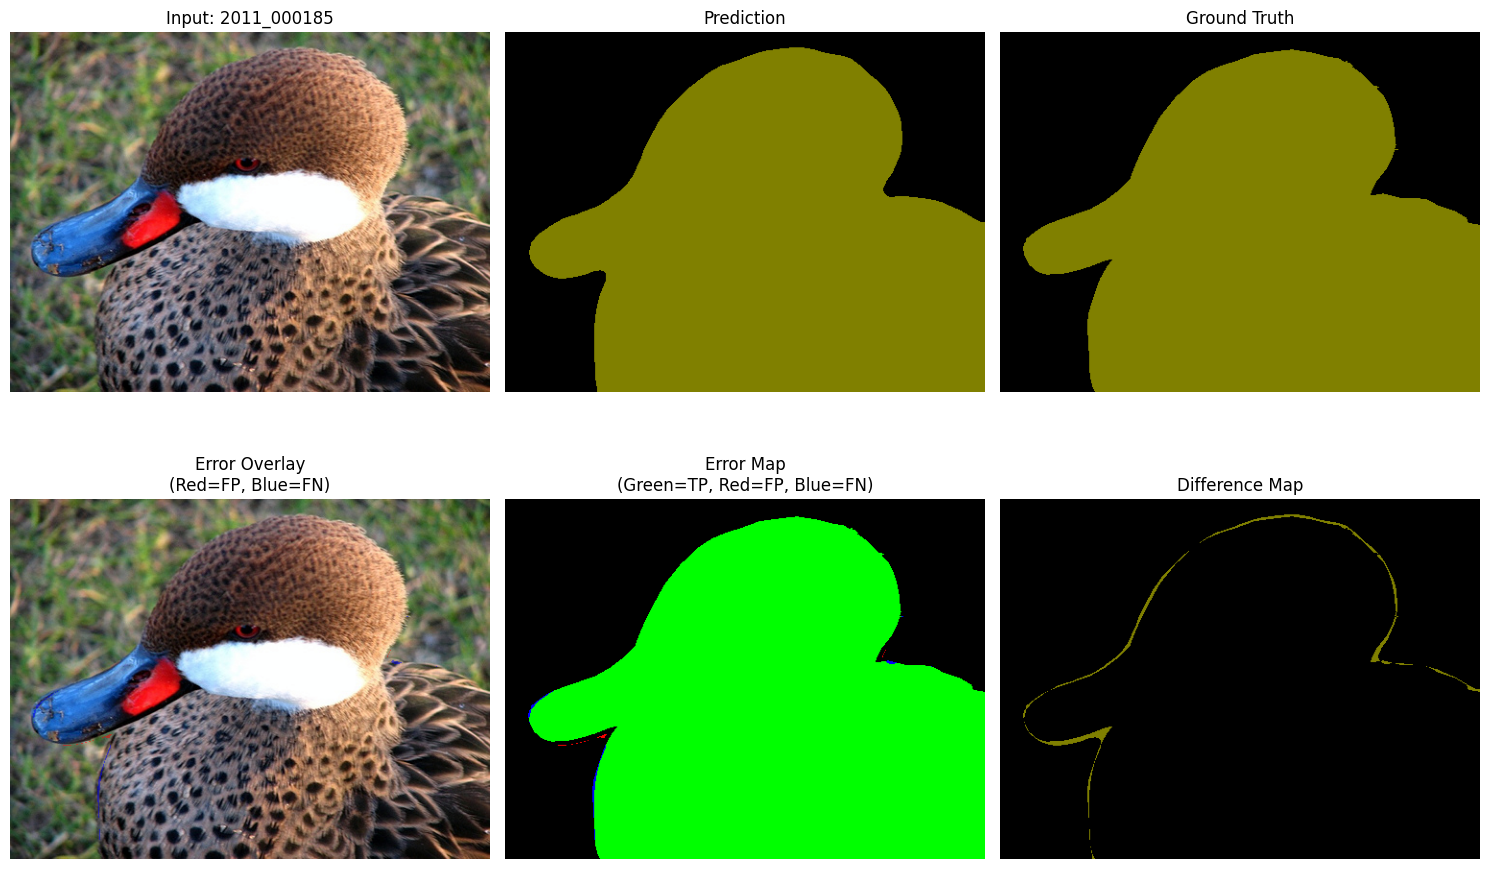

Image: 2011_000185
Foreground pixels: 118466
True Positive (TP): 118259 (99.8%)
False Positive (FP): 42 (extra predictions)
False Negative (FN): 207 (missed regions)
FP + FN total errors: 249
--------------------------------------------------
[Rank 5] Error Rate: 0.22%, FP: 108, FN: 179, FG: 132190


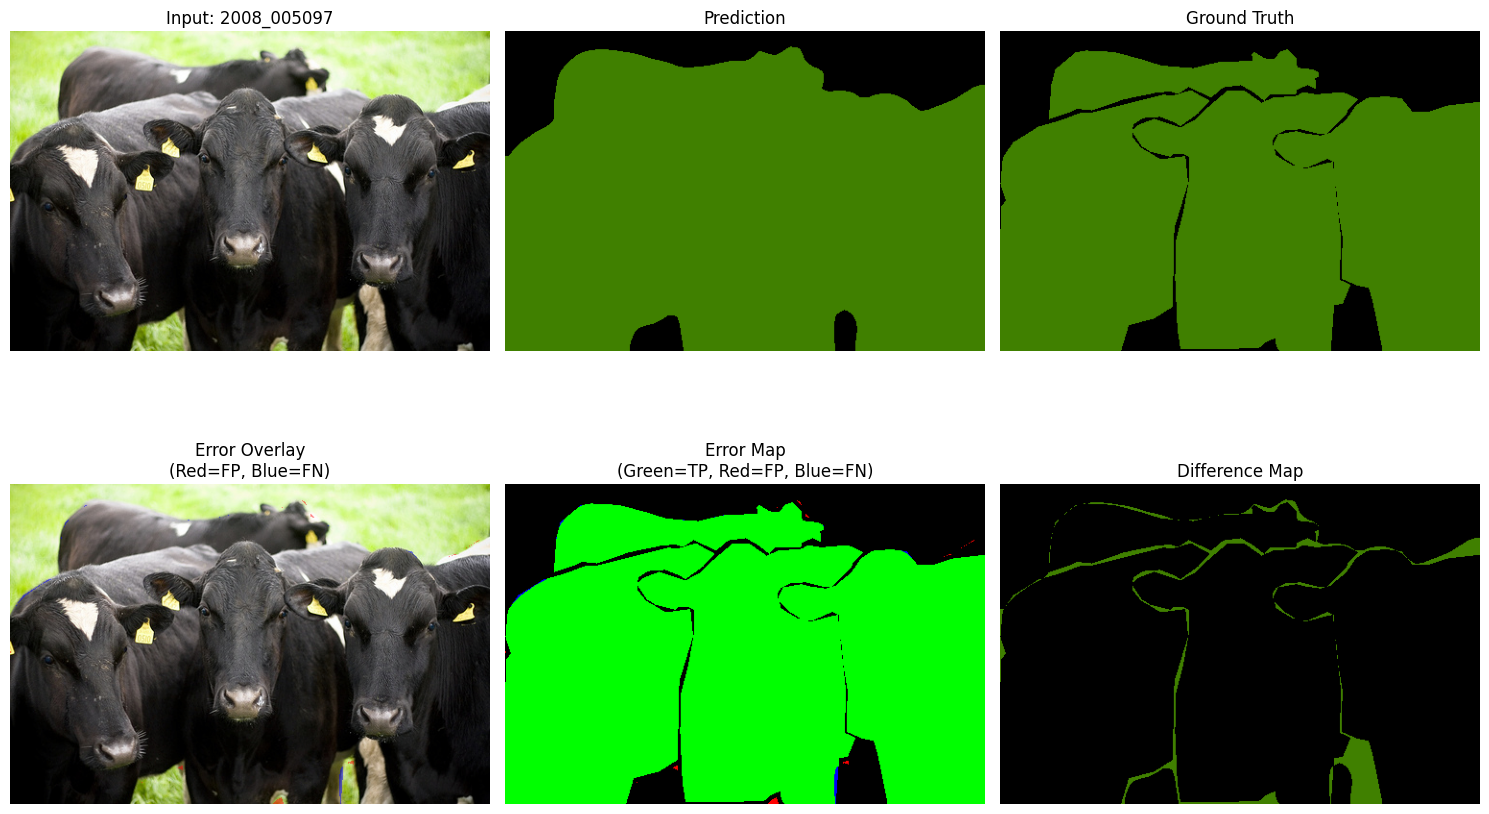

Image: 2008_005097
Foreground pixels: 132190
True Positive (TP): 132011 (99.9%)
False Positive (FP): 108 (extra predictions)
False Negative (FN): 179 (missed regions)
FP + FN total errors: 287
--------------------------------------------------

Finding MOST PROBLEMATIC images...
Evaluating 1449 samples...

Top 3 Most Problematic Images (Highest Error Rate):

[Rank 1] Error Rate: 3357.49%, FP: 8158, FN: 135, FG: 247


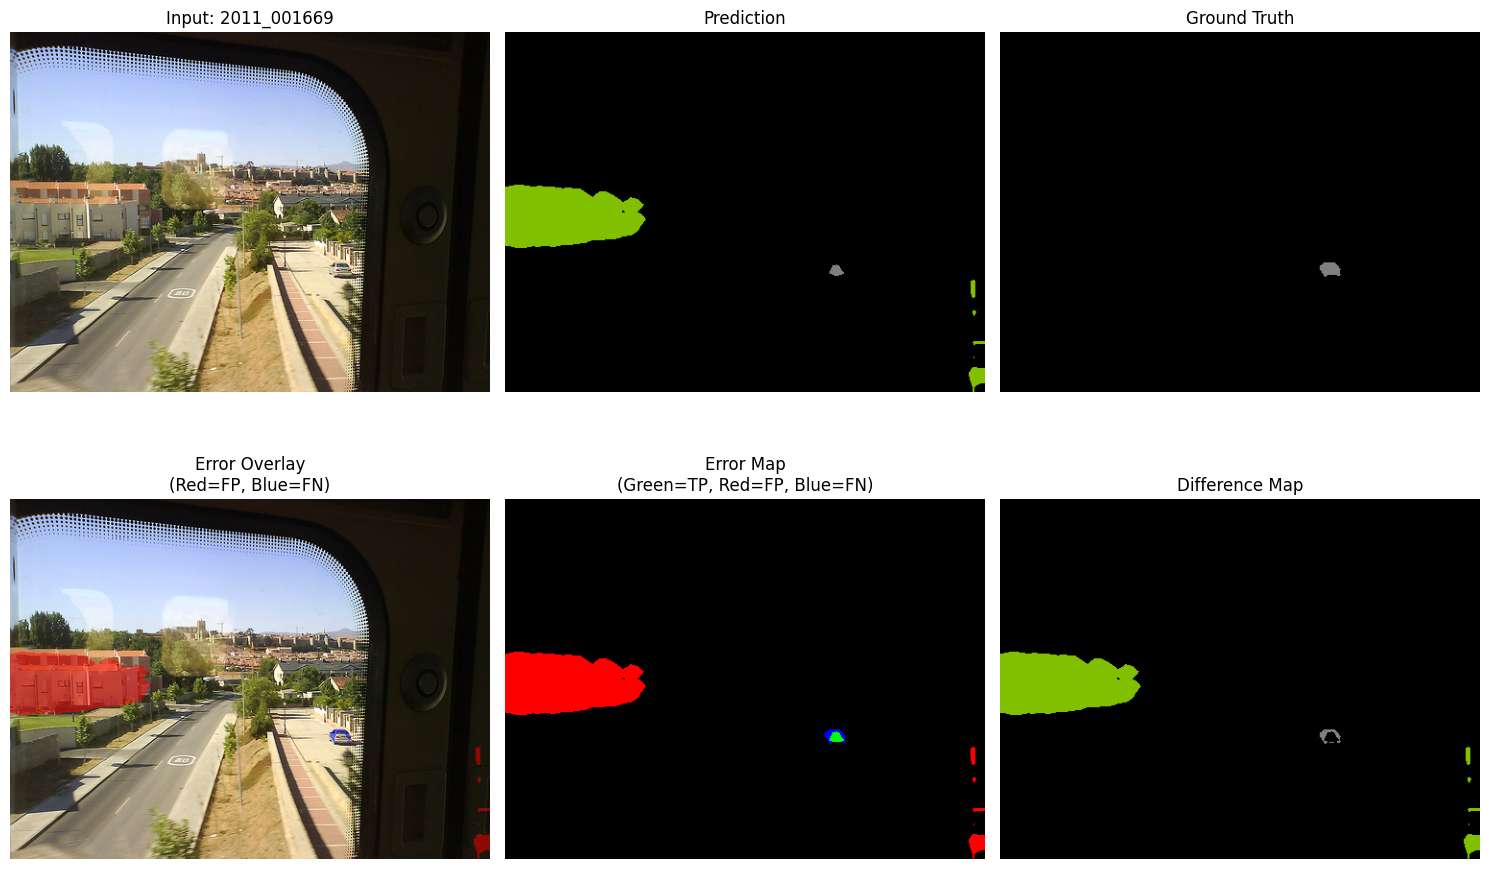

Image: 2011_001669
Foreground pixels: 247
True Positive (TP): 112 (45.3%)
False Positive (FP): 8158 (extra predictions)
False Negative (FN): 135 (missed regions)
FP + FN total errors: 8293
--------------------------------------------------
[Rank 2] Error Rate: 2050.58%, FP: 3468, FN: 59, FG: 172


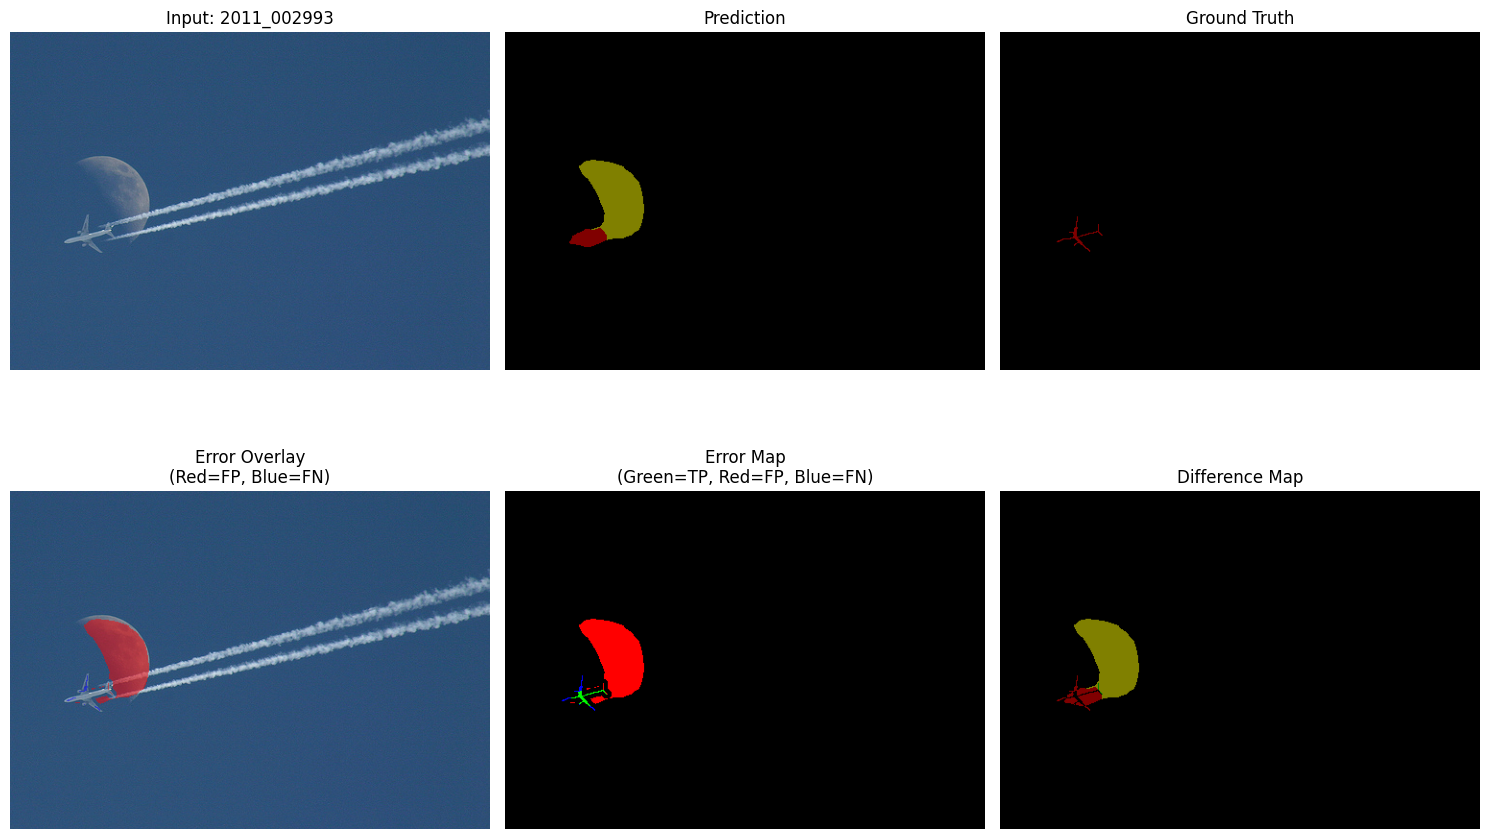

Image: 2011_002993
Foreground pixels: 172
True Positive (TP): 103 (59.9%)
False Positive (FP): 3468 (extra predictions)
False Negative (FN): 59 (missed regions)
FP + FN total errors: 3527
--------------------------------------------------
[Rank 3] Error Rate: 749.18%, FP: 143828, FN: 0, FG: 19198


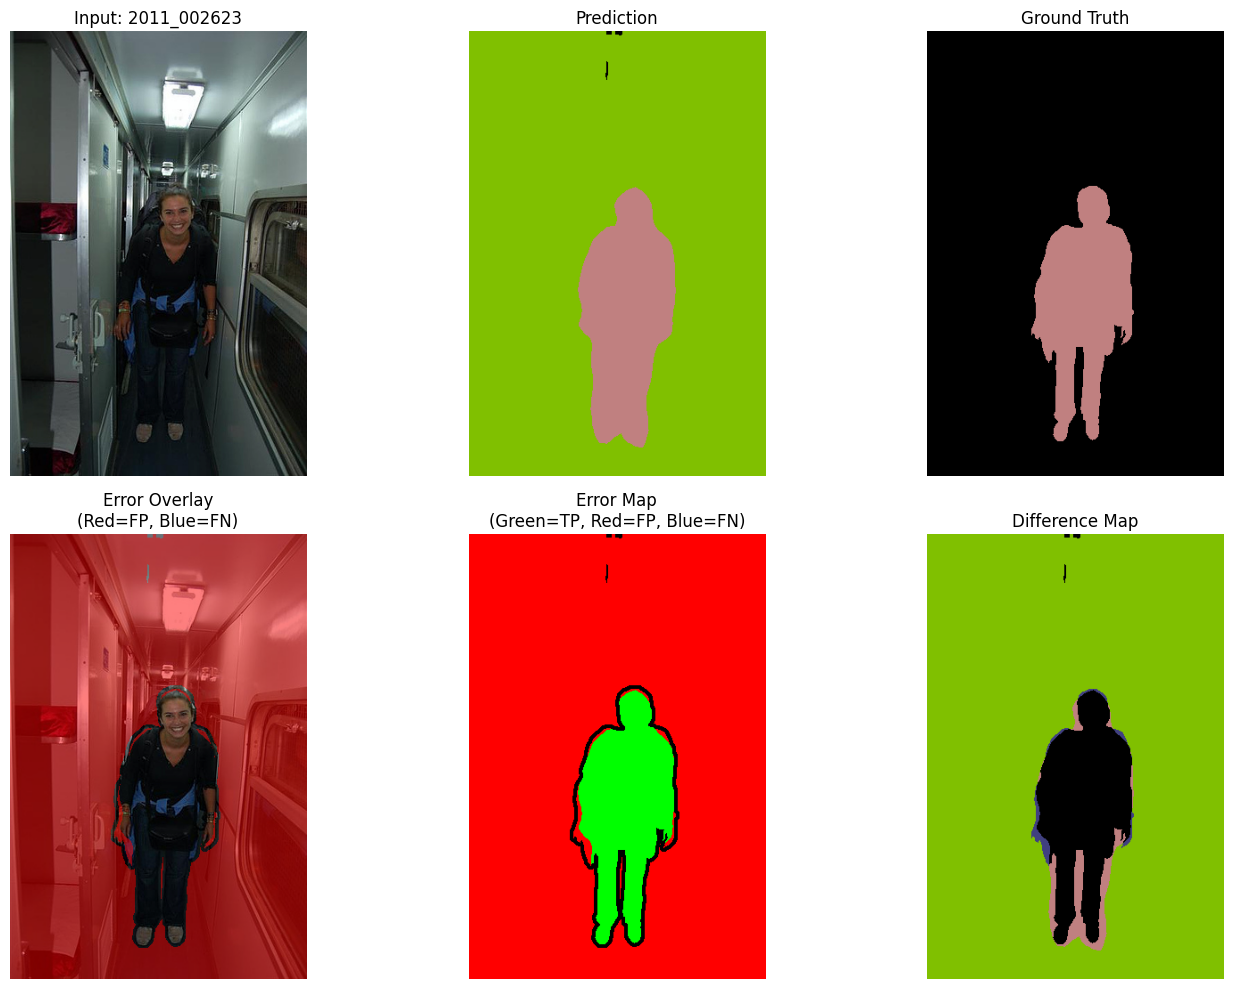

Image: 2011_002623
Foreground pixels: 19198
True Positive (TP): 18354 (95.6%)
False Positive (FP): 143828 (extra predictions)
False Negative (FN): 0 (missed regions)
FP + FN total errors: 143828
--------------------------------------------------


In [57]:
# ========== Visualization with Error Analysis ==========

import matplotlib.pyplot as plt
import numpy as np

VOC_COLORS = [
    [0, 0, 0],        # 0: background
    [128, 0, 0],      # 1: aeroplane
    [0, 128, 0],      # 2: bicycle
    [128, 128, 0],    # 3: bird
    [0, 0, 128],      # 4: boat
    [128, 0, 128],    # 5: bottle
    [0, 128, 128],    # 6: bus
    [128, 128, 128],  # 7: car
    [64, 0, 0],       # 8: cat
    [192, 0, 0],      # 9: chair
    [64, 128, 0],     # 10: cow
    [192, 128, 0],    # 11: dining table
    [64, 0, 128],     # 12: dog
    [192, 0, 128],    # 13: horse
    [64, 128, 128],   # 14: motorbike
    [192, 128, 128],  # 15: person
    [0, 64, 0],       # 16: potted plant
    [128, 64, 0],     # 17: sheep
    [0, 192, 0],      # 18: sofa
    [128, 192, 0],    # 19: train
    [0, 64, 128],     # 20: tv/monitor
]

VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'dining table', 'dog', 'horse', 'motorbike',
    'person', 'potted plant', 'sheep', 'sofa', 'train',
    'tv/monitor'
]


def decode_segmap(segmap, colors=VOC_COLORS):
    """Convert segmentation map to color image"""
    h, w = segmap.shape
    color_map = np.zeros((h, w, 3), dtype=np.uint8)
    for i, color in enumerate(colors):
        color_map[segmap == i] = color
    return color_map


def visualize_with_errors(model, dataset, idx=0, device=None):
    """Visualize prediction with error analysis - shows FP and FN clearly"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    
    # Get image and label
    image, label = dataset[idx]
    image_batch = image.unsqueeze(0).to(device)
    img_id = dataset.img_ids[idx]
    
    with torch.no_grad():
        output = model(image_batch)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    label_np = label.numpy()
    
    # Create error map
    # Green: Correct (TP)
    # Red: False Positive (predicted but wrong)
    # Blue: False Negative (missed ground truth)
    error_map = np.zeros((*pred.shape, 3), dtype=np.uint8)
    
    # Ignore label (255)
    valid_mask = (label_np != 255)
    
    # True Positive (correct prediction)
    tp_mask = (pred == label_np) & valid_mask & (label_np != 0)  # Exclude background
    error_map[tp_mask] = [0, 255, 0]  # Green
    
    # False Positive (predicted something but wrong)
    fp_mask = (pred != label_np) & valid_mask & (pred != 0)  # Model predicted foreground but wrong
    error_map[fp_mask] = [255, 0, 0]  # Red
    
    # False Negative (missed ground truth)
    fn_mask = (pred != label_np) & valid_mask & (label_np != 0) & (pred == 0)  # Should be foreground but missed
    error_map[fn_mask] = [0, 0, 255]  # Blue
    
    # Calculate statistics
    tp = tp_mask.sum()
    fp = fp_mask.sum()
    fn = fn_mask.sum()
    
    # Foreground pixels only
    fg_mask = (label_np != 0) & (label_np != 255)
    fg_pixels = fg_mask.sum()
    
    # Denormalize image
    image_show = image.cpu().numpy().transpose(1, 2, 0)
    image_mean = np.array([103.53, 116.28, 123.675])
    image_std = np.array([57.375, 57.120, 58.395])
    image_show = (image_show * image_std + image_mean).astype(np.uint8)
    image_show = image_show[:, :, ::-1]  # BGR -> RGB
    
    # Decode segmentation
    pred_color = decode_segmap(pred)
    label_color = decode_segmap(label_np)
    
    # Create overlay showing errors on original image
    overlay = image_show.copy()
    # Red for FP
    overlay[fp_mask] = (overlay[fp_mask] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
    # Blue for FN
    overlay[fn_mask] = (overlay[fn_mask] * 0.5 + np.array([0, 0, 255]) * 0.5).astype(np.uint8)
    
    # Display - 2 rows
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Original results
    axes[0, 0].imshow(image_show)
    axes[0, 0].set_title(f'Input: {img_id}', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(pred_color)
    axes[0, 1].set_title('Prediction', fontsize=12)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(label_color)
    axes[0, 2].set_title('Ground Truth', fontsize=12)
    axes[0, 2].axis('off')
    
    # Row 2: Error analysis
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title('Error Overlay\n(Red=FP, Blue=FN)', fontsize=12)
    axes[1, 0].axis('off')
    
    # Error map only
    axes[1, 1].imshow(error_map)
    axes[1, 1].set_title('Error Map\n(Green=TP, Red=FP, Blue=FN)', fontsize=12)
    axes[1, 1].axis('off')
    
    # Prediction vs GT difference
    diff = np.abs(pred_color.astype(int) - label_color.astype(int)).astype(np.uint8)
    axes[1, 2].imshow(diff)
    axes[1, 2].set_title('Difference Map', fontsize=12)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f'Image: {img_id}')
    print(f'Foreground pixels: {fg_pixels}')
    print(f'True Positive (TP): {tp} ({tp/max(fg_pixels,1)*100:.1f}%)')
    print(f'False Positive (FP): {fp} (extra predictions)')
    print(f'False Negative (FN): {fn} (missed regions)')
    print(f'FP + FN total errors: {fp + fn}')
    print('-' * 50)
    
    model.train()
    
    return {'tp': tp, 'fp': fp, 'fn': fn, 'img_id': img_id}


def find_best_segmentation(model, dataset, num_samples=100, top_k=5, device=None):
    """Find images with LEAST errors (lowest FP+FN), not just highest IoU"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    results = []
    
    print(f'Evaluating {min(num_samples, len(dataset))} samples...')
    
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            image, label = dataset[i]
            image_batch = image.unsqueeze(0).to(device)
            
            output = model(image_batch)
            pred = output.argmax(dim=1).squeeze().cpu().numpy()
            label_np = label.numpy()
            
            valid_mask = (label_np != 255)
            fg_mask = (label_np != 0) & valid_mask
            
            # Calculate errors
            tp = ((pred == label_np) & fg_mask).sum()
            fp = ((pred != label_np) & (pred != 0) & valid_mask).sum()
            fn = ((pred != label_np) & (label_np != 0) & (pred == 0) & valid_mask).sum()
            
            fg_pixels = fg_mask.sum()
            
            # Error rate (lower is better)
            if fg_pixels > 100:  # Only consider images with enough foreground
                error_rate = (fp + fn) / fg_pixels
                results.append((i, error_rate, fp, fn, fg_pixels))
    
    # Sort by error rate (ascending - lowest errors first)
    results.sort(key=lambda x: x[1])
    
    print(f'\n{"="*60}')
    print(f'Top {top_k} Best Segmentations (Lowest Error Rate):')
    print(f'{"="*60}\n')
    
    for rank, (idx, error_rate, fp, fn, fg_pixels) in enumerate(results[:top_k]):
        print(f'[Rank {rank+1}] Error Rate: {error_rate:.2%}, FP: {fp}, FN: {fn}, FG: {fg_pixels}')
        visualize_with_errors(model, dataset, idx=idx, device=device)
    
    return results[:top_k]


def find_problematic_images(model, dataset, num_samples=100, top_k=5, device=None):
    """Find images with MOST errors for analysis"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    results = []
    
    print(f'Evaluating {min(num_samples, len(dataset))} samples...')
    
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            image, label = dataset[i]
            image_batch = image.unsqueeze(0).to(device)
            
            output = model(image_batch)
            pred = output.argmax(dim=1).squeeze().cpu().numpy()
            label_np = label.numpy()
            
            valid_mask = (label_np != 255)
            fg_mask = (label_np != 0) & valid_mask
            
            fp = ((pred != label_np) & (pred != 0) & valid_mask).sum()
            fn = ((pred != label_np) & (label_np != 0) & (pred == 0) & valid_mask).sum()
            fg_pixels = fg_mask.sum()
            
            if fg_pixels > 100:
                error_rate = (fp + fn) / fg_pixels
                results.append((i, error_rate, fp, fn, fg_pixels))
    
    # Sort by error rate (descending - highest errors first)
    results.sort(key=lambda x: x[1], reverse=True)
    
    print(f'\n{"="*60}')
    print(f'Top {top_k} Most Problematic Images (Highest Error Rate):')
    print(f'{"="*60}\n')
    
    for rank, (idx, error_rate, fp, fn, fg_pixels) in enumerate(results[:top_k]):
        print(f'[Rank {rank+1}] Error Rate: {error_rate:.2%}, FP: {fp}, FN: {fn}, FG: {fg_pixels}')
        visualize_with_errors(model, dataset, idx=idx, device=device)
    
    return results[:top_k]


# ========== Run ==========

val_dataset = VOCSegDataset(voc_path, split='val', crop_size=513, is_training=False)

# Find BEST (lowest error rate)
print('\n' + '='*60)
print('Finding BEST segmentations (lowest error rate)...')
print('='*60)
best_results = find_best_segmentation(model, val_dataset, num_samples=1449, top_k=5, device=device)

# Find WORST (highest error rate)
print('\n' + '='*60)
print('Finding MOST PROBLEMATIC images...')
print('='*60)
worst_results = find_problematic_images(model, val_dataset, num_samples=1449, top_k=3, device=device)


In [54]:
# 计算 mIoU
miou = evaluate_model(model, val_loader, config['num_classes'], 
                       config['ignore_label'], device)
print(f'最终验证 mIoU: {miou:.4f}')

验证中: 100%|██████████| 1449/1449 [00:26<00:00, 53.72it/s]

最终验证 mIoU: 0.7483
